# AI Powered Personalized Content Recommendation System

 ## Introduction
This project explores how user data can be used to create simple personalized content recommendations.

Instead of using a complex machine learning model, I built a candidate-based rule system that compares possible content options and selects the best match with the recommendation.  

The goal is to combine data analysis, statistics, visualization, and basic Python programming concepts in one complete project.

I wanted to keep the recommendation logic simple enough to understand and explain clearly, while still making it realistic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


## Dataset Overview

Since this is a learning project, using a synthetic dataset allowed me to control the columns and include realistic issues such as missing values and inconsistent categories.

### Loading and Inspecting the Dataset
In this section, I loaded the AI generated user dataset and inspected its structure. 
This step helps us understand the number of rows, columns, data types, missing values, and give the first observations.

The dataset was created for this project to simulate realistic user profiles and content interactions. 
Each row represents a user profile combined with one content interaction.

In [2]:
df = pd.read_csv("users_generated_dataset_enriched.csv")
df.head()

,user_id,name,age,interest,preferred_format,activity_type,content_category,content_format,content_popularity,engagement_score,recommended_content,time_spent_minutes,clicks_count,previous_interactions,user_rating,activity_hour,recommendation_score
0,1,Carter Taylor,20,education,tutorial,shared,education,tutorial,43,65.0,Study skills tutorial,34.2,5.0,7,4.0,19,65.0
1,2,Grace Smith,46,technology,tutorial,shared,technology,tutorial,24,73.0,Tech trends newsletter,30.5,5.0,15,4.1,10,66.6
2,3,Ella Johnson,40,movies,video,viewed,finance,video,79,50.0,Market update podcast,16.8,5.0,12,3.0,7,66.0
3,4,Samuel Wilson,58,education,newsletter,completed,fashion,newsletter,57,58.0,Fashion newsletter,15.2,6.0,2,3.1,9,59.5
4,5,Ella Davis,47,travel,newsletter,viewed,travel,newsletter,74,66.0,Budget travel newsletter,2.4,8.0,9,4.1,13,76.0


In [3]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns)

Dataset shape: (1000, 17)
Columns:
Index(['user_id', 'name', 'age', 'interest', 'preferred_format',
       'activity_type', 'content_category', 'content_format',
       'content_popularity', 'engagement_score', 'recommended_content',
       'time_spent_minutes', 'clicks_count', 'previous_interactions',
       'user_rating', 'activity_hour', 'recommendation_score'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                1000 non-null   int64  
 1   name                   1000 non-null   object 
 2   age                    1000 non-null   int64  
 3   interest               1000 non-null   object 
 4   preferred_format       994 non-null    object 
 5   activity_type          1000 non-null   object 
 6   content_category       1000 non-null   object 
 7   content_format         1000 non-null   object 
 8   content_popularity     1000 non-null   int64  
 9   engagement_score       995 non-null    float64
 10  recommended_content    995 non-null    object 
 11  time_spent_minutes     996 non-null    float64
 12  clicks_count           997 non-null    float64
 13  previous_interactions  1000 non-null   int64  
 14  user_rating            996 non-null    float64
 15  activ

The dataset contains 1000 rows and 17 columns. 
It includes both categorical variables, such as user interests and content formats, and numerical variables, such as age, engagement score, time spent, clicks count, user rating, and recommendation score.

Some columns contain missing values, especially preferred_format, engagement_score, recommended_content, time_spent_minutes, clicks_count, and user_rating.

### Basic Data Exploration

In [5]:
df.describe()

,user_id,age,content_popularity,engagement_score,time_spent_minutes,clicks_count,previous_interactions,user_rating,activity_hour,recommendation_score
count,1000.000000,1000.000000,1000.000000,995.000000,996.000000,997.000000,1000.000000,996.000000,1000.000000,1000.000000
mean,494.898000,41.909000,60.442000,65.044221,21.219277,5.820461,11.831000,3.591064,14.001000,70.084900
std,288.188331,13.843495,19.521058,14.095608,10.670182,2.570856,3.565831,0.789345,5.098725,13.631812
min,1.000000,18.000000,1.000000,20.000000,1.900000,0.000000,1.000000,1.000000,0.000000,25.600000
25%,244.750000,30.000000,48.000000,56.000000,12.900000,4.000000,9.000000,3.100000,10.000000,61.275000
50%,494.500000,42.000000,61.000000,66.000000,20.200000,6.000000,12.000000,3.600000,15.000000,70.600000
75%,744.250000,54.000000,74.000000,75.000000,28.100000,7.000000,14.000000,4.125000,18.000000,79.600000
max,994.000000,65.000000,100.000000,100.000000,64.500000,18.000000,25.000000,5.000000,23.000000,100.000000


The descriptive statistics show that users are between 18 and 65 years old, with an average age of around 42. 
The average content popularity is about 60, which suggests that most users interact with moderately popular content.

The average engagement score is about 65, meaning that user engagement is generally positive but not perfect. 
Users spend around 21 minutes on average with content, and the average user rating is around 3.6 out of 5.

The dataset also includes a recommendation_score column with an average of about 70. 
This gives an initial numerical indicator of recommendation quality. I will later create my own candidate score for the recommendation engine.

In [6]:
df.isnull().sum()

user_id                  0
name                     0
age                      0
interest                 0
preferred_format         6
activity_type            0
content_category         0
content_format           0
content_popularity       0
engagement_score         5
recommended_content      5
time_spent_minutes       4
clicks_count             3
previous_interactions    0
user_rating              4
activity_hour            0
recommendation_score     0
dtype: int64

The dataset contains a small number of missing values. 
The missing values are mainly found in preferred_format, engagement_score, recommended_content, time_spent_minutes, clicks_count, and user_rating.

In [7]:
df.duplicated().sum()

0

In [8]:
df["user_id"].duplicated().sum()

6

Although there are no fully duplicated rows, there are 6 duplicated user IDs. 
This means that some users appear more than once in the dataset. 
This could be normal because one user can interact with multiple pieces of content.

In [9]:
df.nunique()

user_id                  994
name                     668
age                       48
interest                  16
preferred_format           6
activity_type              6
content_category          15
content_format             6
content_popularity        93
engagement_score          73
recommended_content       40
time_spent_minutes       371
clicks_count              16
previous_interactions     25
user_rating               40
activity_hour             24
recommendation_score     424
dtype: int64

The nunique() results show the number of unique values in each column. 
The dataset has 994 unique user IDs, which confirms that a few user IDs appear more than once. 

The interest column has 16 unique values and content_category has 15 unique values, even though we expected only 10 categories. 
This suggests that some category names have duplicates or errors. 

In [10]:
print("Interest values:")
print(df["interest"].unique())

print("\nContent category values:")
print(df["content_category"].unique())

print("\nPreferred format values:")
print(df["preferred_format"].unique())

Interest values:
['education' 'technology' 'movies' 'travel' 'music' 'gaming' 'finance'
 'fashion' 'cooking' 'fitness' 'Fashion' 'Movies' 'Education' 'Fitness'
 'Technology' 'Travel']

Content category values:
['education' 'technology' 'finance' 'fashion' 'travel' 'music' 'movies'
 'fitness' 'cooking' 'gaming' 'EDUCATION' 'MUSIC' 'GAMING' 'FITNESS'
 'FASHION']

Preferred format values:
['tutorial' 'video' 'newsletter' 'playlist' 'podcast' 'blog' nan]


### Data Cleaning and Preprocessing

In [11]:
df_clean = df.copy()

# Standardize text columns to lowercase
df_clean["interest"] = df_clean["interest"].str.lower()
df_clean["content_category"] = df_clean["content_category"].str.lower()
df_clean["preferred_format"] = df_clean["preferred_format"].str.lower()
df_clean["activity_type"] = df_clean["activity_type"].str.lower()
df_clean["content_format"] = df_clean["content_format"].str.lower()

# Fill missing categorical values
df_clean["preferred_format"] = df_clean["preferred_format"].fillna("unknown")
df_clean["recommended_content"] = df_clean["recommended_content"].fillna("Unknown recommendation")

# Fill missing numerical values with the median
df_clean["engagement_score"] = df_clean["engagement_score"].fillna(df_clean["engagement_score"].median())
df_clean["time_spent_minutes"] = df_clean["time_spent_minutes"].fillna(df_clean["time_spent_minutes"].median())
df_clean["clicks_count"] = df_clean["clicks_count"].fillna(df_clean["clicks_count"].median())
df_clean["user_rating"] = df_clean["user_rating"].fillna(df_clean["user_rating"].median())

# Check missing values after cleaning
df_clean.isnull().sum()

user_id                  0
name                     0
age                      0
interest                 0
preferred_format         0
activity_type            0
content_category         0
content_format           0
content_popularity       0
engagement_score         0
recommended_content      0
time_spent_minutes       0
clicks_count             0
previous_interactions    0
user_rating              0
activity_hour            0
recommendation_score     0
dtype: int64

In [12]:
print(df_clean["interest"].unique())
print(df_clean["content_category"].unique())
print(df_clean["preferred_format"].unique())

['education' 'technology' 'movies' 'travel' 'music' 'gaming' 'finance'
 'fashion' 'cooking' 'fitness']
['education' 'technology' 'finance' 'fashion' 'travel' 'music' 'movies'
 'fitness' 'cooking' 'gaming']
['tutorial' 'video' 'newsletter' 'playlist' 'podcast' 'blog' 'unknown']


In [13]:
df_clean.head()

,user_id,name,age,interest,preferred_format,activity_type,content_category,content_format,content_popularity,engagement_score,recommended_content,time_spent_minutes,clicks_count,previous_interactions,user_rating,activity_hour,recommendation_score
0,1,Carter Taylor,20,education,tutorial,shared,education,tutorial,43,65.0,Study skills tutorial,34.2,5.0,7,4.0,19,65.0
1,2,Grace Smith,46,technology,tutorial,shared,technology,tutorial,24,73.0,Tech trends newsletter,30.5,5.0,15,4.1,10,66.6
2,3,Ella Johnson,40,movies,video,viewed,finance,video,79,50.0,Market update podcast,16.8,5.0,12,3.0,7,66.0
3,4,Samuel Wilson,58,education,newsletter,completed,fashion,newsletter,57,58.0,Fashion newsletter,15.2,6.0,2,3.1,9,59.5
4,5,Ella Davis,47,travel,newsletter,viewed,travel,newsletter,74,66.0,Budget travel newsletter,2.4,8.0,9,4.1,13,76.0


In [14]:
df_clean["first_name"] = df_clean["name"].apply(lambda x: x.split()[0])
df_clean["last_name"] = df_clean["name"].apply(lambda x: x.split()[-1])

I also extracted first and last names from the name column. 
This is not essential for the recommendation system, but it shows a simple example of text transformation using apply and lambda.

In [15]:
df_clean.isnull().sum()

user_id                  0
name                     0
age                      0
interest                 0
preferred_format         0
activity_type            0
content_category         0
content_format           0
content_popularity       0
engagement_score         0
recommended_content      0
time_spent_minutes       0
clicks_count             0
previous_interactions    0
user_rating              0
activity_hour            0
recommendation_score     0
first_name               0
last_name                0
dtype: int64

In [16]:
df_clean.nunique()

user_id                  994
name                     668
age                       48
interest                  10
preferred_format           7
activity_type              6
content_category          10
content_format             6
content_popularity        93
engagement_score          73
recommended_content       41
time_spent_minutes       371
clicks_count              16
previous_interactions     25
user_rating               40
activity_hour             24
recommendation_score     424
first_name                40
last_name                 30
dtype: int64

At this point, the dataset is easier to work with because the categories are consistent and the missing values have been handled. 
The cleaned dataset contains no missing values. 
The number of unique values also confirms that the main categorical columns are now standardized.

The interest and content_category columns both contain 10 unique values, which matches the expected number of categories. 
The preferred_format column contains 7 unique values because missing values were replaced with "unknown".

There are 994 unique user IDs for 1000 rows, meaning that a few users appear more than once. 
This can be acceptable in an interaction-based recommendation dataset.

### Exploratory Data Analysis

#### Most Common User Interests

In [17]:
df_clean["interest"].value_counts()

technology    157
fitness       130
music         129
education     127
gaming        116
movies         91
finance        69
travel         67
fashion        60
cooking        54
Name: interest, dtype: int64

Technology is the most common user interest in the dataset, followed by fitness, music, education, and gaming. 
The least common interests are cooking, fashion, travel, and finance.

This suggests that the dataset contains more users interested in digital, active, or entertainment-related topics, while lifestyle and finance categories are less represented.

#### Most Common Activity Types

In [18]:
df_clean["activity_type"].value_counts()

viewed       499
liked        194
shared        96
saved         90
completed     78
purchased     43
Name: activity_type, dtype: int64

The most common activity type is viewed, with 499 interactions. 
This result makes sense to me because viewing content is usually the first and easiest action a user can take. 
Purchased is the least common activity type, which is realistic because buying requires more user commitment than simply viewing or liking content.

#### Engagement Score Overview

In [19]:
average_engagement = df_clean["engagement_score"].mean()
median_engagement = df_clean["engagement_score"].median()

print("Average engagement score:", average_engagement)
print("Median engagement score:", median_engagement)

Average engagement score: 65.049
Median engagement score: 66.0


The average engagement score is 65.05, while the median engagement score is 66.0. 
Since these two values are very close, the engagement scores appear to be relatively balanced and not strongly affected by extreme values.

The engagement_score column is synthetic. 
It was generated to simulate user engagement based on realistic patterns, such as interest match, preferred content format, activity type, and content popularity.

#### NumPy Summary Statistics

I used NumPy to calculate summary statistics for the engagement_score column. 
This helps me understand the general level of engagement and how spread out the scores are.

In [20]:
engagement_scores = df_clean["engagement_score"].to_numpy()

engagement_mean = np.mean(engagement_scores)
engagement_median = np.median(engagement_scores)
engagement_std = np.std(engagement_scores)
engagement_min = np.min(engagement_scores)
engagement_max = np.max(engagement_scores)

print("Mean engagement score:", engagement_mean)
print("Median engagement score:", engagement_median)
print("Standard deviation:", engagement_std)
print("Minimum engagement score:", engagement_min)
print("Maximum engagement score:", engagement_max)

Mean engagement score: 65.049
Median engagement score: 66.0
Standard deviation: 14.053419477123708
Minimum engagement score: 20.0
Maximum engagement score: 100.0


The mean and median engagement scores are very close, which suggests that the engagement distribution is fairly balanced.

The standard deviation shows how much engagement scores vary around the mean. 
In this dataset, the engagement scores show some variation, but they are not extremely spread out.

The minimum and maximum values show the full range of engagement scores in the dataset.

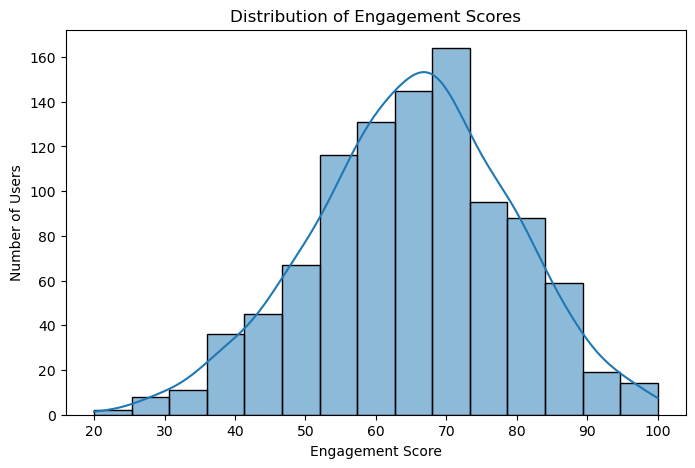

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="engagement_score",
    bins=15,
    kde=True
)

plt.title("Distribution of Engagement Scores")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Users")
plt.show()

Most scores are concentrated around the middle-to-high range, which matches the average engagement score found with NumPy.

#### Average Engagement by Content Category

In [22]:
engagement_by_category = df_clean.groupby("content_category")["engagement_score"].mean().sort_values(ascending=False)

engagement_by_category

content_category
fitness       67.526316
education     67.431034
technology    66.161538
movies        65.273684
music         65.050000
gaming        64.632000
travel        64.602941
finance       63.392405
cooking       62.689189
fashion       60.784810
Name: engagement_score, dtype: float64

Fitness, education, and technology have the highest average engagement scores. 
This suggests that users in this dataset tend to interact more strongly with practical or learning-oriented content.

Fashion has the lowest average engagement score, followed by cooking and finance. 
However, the differences between categories are not extremely large, so the engagement level remains relatively balanced across content types.

#### Average Engagement by Content Format

In [23]:
engagement_by_format = df_clean.groupby("content_format")["engagement_score"].mean().sort_values(ascending=False)

engagement_by_format

content_format
newsletter    66.234375
blog          65.945055
video         65.715640
tutorial      65.647668
podcast       63.938650
playlist      61.878049
Name: engagement_score, dtype: float64

Newsletter, blog, video, and tutorial formats have the highest average engagement scores. 
This suggests that users may engage slightly more with informative or educational content formats.

Playlist has the lowest average engagement score in this dataset. 
However, the differences between formats are relatively small, so no format clearly dominates the others.

#### Age Distribution

In [24]:
df_clean["age"].describe()

count    1000.000000
mean       41.909000
std        13.843495
min        18.000000
25%        30.000000
50%        42.000000
75%        54.000000
max        65.000000
Name: age, dtype: float64

The users are between 18 and 65 years old, with an average age of about 42. 

The median age is also 42, which suggests that the age distribution is relatively balanced.

The first quartile is 30, meaning that 25% of users are 30 years old or younger.

The third quartile is 54, meaning that 75% of users are 54 years old or younger.

#### Peak Activity Hours

In [25]:
activity_by_hour = df_clean["activity_hour"].value_counts().sort_index()

activity_by_hour

0     16
1      6
2      3
3      3
4      4
5     14
6     21
7     43
8     44
9     58
10    59
11    45
12    62
13    65
14    55
15    65
16    46
17    95
18    88
19    70
20    55
21    40
22    20
23    23
Name: activity_hour, dtype: int64

In [26]:
peak_hour = activity_by_hour.idxmax()
peak_activity_count = activity_by_hour.max()

print("Peak activity hour:", peak_hour)
print("Number of activities at peak hour:", peak_activity_count)

Peak activity hour: 17
Number of activities at peak hour: 95


The activity_hour column shows when user interactions happened during the day. 
By counting activities per hour, we can identify the peak activity time in the dataset.
The peak activity hour is 17h, with 95 user interactions. 
This means that the highest number of interactions happened around 5 PM.

This may suggest that users are more active in the late afternoon, possibly after work or school hours.

#### Numerical Correlation Overview

In [27]:
numeric_columns = [
    "age", "content_popularity", "engagement_score", 
    "time_spent_minutes", "clicks_count", "previous_interactions", 
    "user_rating", "activity_hour", "recommendation_score"
]

correlation_matrix = df_clean[numeric_columns].corr()

correlation_matrix

,age,content_popularity,engagement_score,time_spent_minutes,clicks_count,previous_interactions,user_rating,activity_hour,recommendation_score
age,1.000000,-0.031366,-0.037791,-0.034528,0.001119,0.025016,-0.020892,-0.063504,-0.033942
content_popularity,-0.031366,1.000000,0.462324,-0.005859,0.101000,0.135991,0.356875,0.041400,0.760739
engagement_score,-0.037791,0.462324,1.000000,0.182583,0.296051,0.230804,0.716093,0.013599,0.892922
time_spent_minutes,-0.034528,-0.005859,0.182583,1.000000,0.097695,0.080628,0.125300,-0.048883,0.126518
clicks_count,0.001119,0.101000,0.296051,0.097695,1.000000,0.110642,0.176622,0.001008,0.243266
previous_interactions,0.025016,0.135991,0.230804,0.080628,0.110642,1.000000,0.132383,0.028143,0.307753
user_rating,-0.020892,0.356875,0.716093,0.125300,0.176622,0.132383,1.000000,-0.006752,0.786882
activity_hour,-0.063504,0.041400,0.013599,-0.048883,0.001008,0.028143,-0.006752,1.000000,0.026197
recommendation_score,-0.033942,0.760739,0.892922,0.126518,0.243266,0.307753,0.786882,0.026197,1.000000


In [28]:
correlation_matrix["engagement_score"].sort_values(ascending=False)

engagement_score         1.000000
recommendation_score     0.892922
user_rating              0.716093
content_popularity       0.462324
clicks_count             0.296051
previous_interactions    0.230804
time_spent_minutes       0.182583
activity_hour            0.013599
age                     -0.037791
Name: engagement_score, dtype: float64

In [29]:
correlation_matrix["recommendation_score"].sort_values(ascending=False)

recommendation_score     1.000000
engagement_score         0.892922
user_rating              0.786882
content_popularity       0.760739
previous_interactions    0.307753
clicks_count             0.243266
time_spent_minutes       0.126518
activity_hour            0.026197
age                     -0.033942
Name: recommendation_score, dtype: float64

The correlation analysis shows that recommendation_score is strongly related to engagement_score, user_rating, and content_popularity. 
This suggests that the recommendation score is mainly influenced by user engagement, user satisfaction, and content popularity.

Engagement_score is also strongly related to user_rating and moderately related to content_popularity. 
This means that users who rate content higher also tend to show stronger engagement, and popular content tends to receive slightly higher engagement.

On the other hand, age and activity_hour have correlations close to zero with both engagement_score and recommendation_score. 
This suggests that, in this synthetic dataset, user age and time of activity are not strong predictors of engagement or recommendation quality.

### Statistical Analysis with SciPy

#### Chi-Square Test: Interest and Activity Type

In [30]:
interest_activity_table = pd.crosstab(df_clean["interest"], df_clean["activity_type"])

interest_activity_table

activity_type,completed,liked,purchased,saved,shared,viewed
interest,,,,,,
cooking,2,12,4,4,4,28
education,11,25,6,9,14,62
fashion,2,12,1,4,12,29
finance,6,9,3,7,7,37
fitness,15,25,7,18,12,53
gaming,11,22,4,6,6,67
movies,7,20,2,13,8,41
music,11,17,4,16,10,71
technology,9,35,8,9,12,84


The cross-tabulation shows that viewed is the most common activity type across almost all interests. 
Technology has the highest number of viewed interactions, followed by music and gaming.

Purchased is the least frequent activity type overall, which is realistic because purchasing requires more commitment than simply viewing or liking content. 
Fitness also shows relatively high completed and saved activity counts, suggesting that users interested in fitness may be more likely to save or finish practical content.

In [31]:
chi2, p_value, dof, expected = stats.chi2_contingency(interest_activity_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 52.375480890376956
P-value: 0.20952938492626957
Degrees of freedom: 45


The chi-square test gives a p-value of 0.2095. 
Since this value is greater than 0.05, we do not find a statistically significant relationship between user interest and activity type.

This means that, in this synthetic dataset, the type of activity does not strongly depend on the user's main interest. 
Although some differences appear in the cross-tabulation table, they are not statistically strong enough to confirm a relationship.

#### Pearson Correlation: Content Popularity and Engagement Score

In [32]:
pearson_corr, pearson_p_value = stats.pearsonr(
    df_clean["content_popularity"],
    df_clean["engagement_score"]
)

print("Pearson correlation:", pearson_corr)
print("P-value:", pearson_p_value)

Pearson correlation: 0.4623236703450534
P-value: 4.191660653775917e-54


The Pearson correlation between content_popularity and engagement_score is 0.4623, which indicates a moderate positive relationship. 
This means that more popular content tends to be associated with higher user engagement.

The p-value is extremely small and below 0.05, so the relationship is statistically significant. 
This suggests that content popularity is meaningfully related to engagement in this synthetic dataset.

However, correlation does not prove causation. 
This result shows that popularity and engagement move together, but it does not prove that popularity directly causes higher engagement.

### Recommendation System

After exploring the data, I used the main patterns to build a simple recommendation logic. 
The goal is to compare one user profile with several possible content options and select the best match.

The original dataset already contains a recommendation_score column from the synthetic data generation process. 
In this section, I create my own candidate_score to show how the recommendation engine chooses the best content option step by step.

#### Recommendation Options DataFrame

In the code, I use the word candidate to describe a possible recommendation option. 
A candidate is not a user here; it is a content option that the system can compare before choosing the final recommendation, so I call it a candidate. 

In [33]:
candidate_contents = df_clean[
    ["content_category", "content_format", "content_popularity", "recommended_content"]
].drop_duplicates().reset_index(drop=True)

candidate_contents.head()

,content_category,content_format,content_popularity,recommended_content
0,education,tutorial,43,Study skills tutorial
1,technology,tutorial,24,Tech trends newsletter
2,finance,video,79,Market update podcast
3,fashion,newsletter,57,Fashion newsletter
4,travel,newsletter,74,Budget travel newsletter


In [34]:
candidate_contents.shape

(960, 4)

The candidate content DataFrame contains 960 unique content options from the cleaned dataset. 
Each candidate includes a content category, content format, popularity score, and recommendation label.

This DataFrame is created after cleaning so the recommendation system compares standardized and reliable content information.

#### Scoring One User Against One Candidate

Before comparing all content options, I first define how to score one candidate for one user. 
This function is the basic scoring rule that will later be applied to every candidate in the candidate content DataFrame.

In [35]:
def score_candidate_for_user(user, candidate):
    score = 10
    
    if user["interest"] == candidate["content_category"]:
        score += 5
        
    if user["preferred_format"] == candidate["content_format"]:
        score += 3
        
    score += candidate["content_popularity"] / 20
    
    return score

This function compares one user profile with one candidate content item. 
The score increases when the candidate category matches the user's interest and when the candidate format matches the user's preferred format.

The popularity score ranges from 1 to 100, so it is divided by 20 to turn it into a smaller bonus between 0 and 5. 
This keeps popularity useful without making it dominate the recommendation score.

This keeps the scoring logic simple while allowing the system to compare different content options.


In [36]:
max_possible_candidate_score = 10 + 5 + 3 + (100 / 20)

print("Maximum possible candidate score:", max_possible_candidate_score)

Maximum possible candidate score: 23.0


The candidate score can reach a maximum of about 23 points. 
This happens when the candidate matches both the user's interest and preferred format, and has the highest possible popularity score.

#### Comparing Candidate Contents for One User

In [37]:
# Select one random user from the cleaned dataset
selected_user = df_clean.sample(1).iloc[0]

# Create a copy of the recommendation options DataFrame
# in order to add scores without changing the original DataFrame
candidate_scores = candidate_contents.copy()

# Calculate a score for each recommendation option
# The same selected user is compared with every option in the DataFrame
candidate_scores["candidate_score"] = candidate_scores.apply(
    lambda candidate: score_candidate_for_user(selected_user, candidate),
    axis=1
)

# Sort the options from the highest score to the lowest score
# Display the top 10 recommendation options for this selected user
candidate_scores.sort_values("candidate_score", ascending=False).head(10)

,content_category,content_format,content_popularity,recommended_content,candidate_score
769,music,playlist,92,New album video review,22.60
119,music,playlist,84,Trending pop playlist,22.20
279,music,playlist,82,Indie music podcast,22.10
552,music,playlist,78,Indie music podcast,21.90
541,music,playlist,75,Indie music podcast,21.75
539,music,playlist,75,Trending pop playlist,21.75
418,music,playlist,74,Indie music podcast,21.70
516,music,playlist,70,Trending pop playlist,21.50
877,music,playlist,68,Indie music podcast,21.40
189,music,playlist,63,New album video review,21.15


The selected user is compared with all candidate contents. 
Each candidate receives a score based on how well it matches the user's interest, preferred format, and the candidate's popularity.

The table is sorted from highest to lowest score, so the first rows represent the strongest recommendation options for this user.

#### Selecting the Best Recommendation

In [38]:
best_candidate = candidate_scores.sort_values(
    "candidate_score",
    ascending=False
).iloc[0]

best_candidate

content_category                        music
content_format                       playlist
content_popularity                         92
recommended_content    New album video review
candidate_score                          22.6
Name: 769, dtype: object

After scoring all candidate contents, the system selects the candidate with the highest score. 
This candidate becomes the final recommendation for the selected user.

In [39]:
selected_user[["name", "age", "interest", "preferred_format"]]

name                Emma Smith
age                         23
interest                 music
preferred_format      playlist
Name: 426, dtype: object

For this selected user, the best candidate matches both the user's interest and preferred format. 
The candidate also has a high popularity score, which increases the final candidate score.

This shows that the system compares all candidate contents and selects the best scoring option.

#### Finding the Best Recommendation with a Function

In [40]:
def find_best_recommendation(user, candidates):
    candidate_scores = candidates.copy()
    
    candidate_scores["candidate_score"] = candidate_scores.apply(
        lambda candidate: score_candidate_for_user(user, candidate),
        axis=1
    )
    
    best_candidate = candidate_scores.sort_values(
        "candidate_score",
        ascending=False
    ).iloc[0]
    
    return best_candidate

In [41]:
best_recommendation = find_best_recommendation(selected_user, candidate_contents)

best_recommendation

content_category                        music
content_format                       playlist
content_popularity                         92
recommended_content    New album video review
candidate_score                          22.6
Name: 769, dtype: object

The find_best_recommendation() function makes the process reusable. 
Instead of manually sorting candidate scores each time, the function compares all candidate contents and returns the best scoring option for a selected user.

#### Applying the Recommendation Engine to All Users (the dataset)

In [42]:
best_recommendations = df_clean.apply(
    lambda user: find_best_recommendation(user, candidate_contents),
    axis=1
)

In [43]:
best_recommendations.head()

,content_category,content_format,content_popularity,recommended_content,candidate_score
0,education,tutorial,93,Study skills tutorial,22.65
1,technology,tutorial,90,AI tutorial video,22.50
2,movies,video,100,Cinema podcast,23.00
3,education,newsletter,97,Learning resources newsletter,22.85
4,travel,newsletter,100,Weekend travel blog,23.00


In [44]:
df_clean["best_recommended_content"] = best_recommendations["recommended_content"]
df_clean["best_candidate_category"] = best_recommendations["content_category"]
df_clean["best_candidate_format"] = best_recommendations["content_format"]
df_clean["best_candidate_score"] = best_recommendations["candidate_score"]

min_score = df_clean["best_candidate_score"].min()
max_score = df_clean["best_candidate_score"].max()

df_clean["normalized_recommendation_score"] = (
    (df_clean["best_candidate_score"] - min_score) / (max_score - min_score)
)

df_clean[[
    "name",
    "interest",
    "preferred_format",
    "best_recommended_content",
    "best_candidate_category",
    "best_candidate_format",
    "best_candidate_score",
    "normalized_recommendation_score"
]].head()

,name,interest,preferred_format,best_recommended_content,best_candidate_category,best_candidate_format,best_candidate_score,normalized_recommendation_score
0,Carter Taylor,education,tutorial,Study skills tutorial,education,tutorial,22.65,0.883333
1,Grace Smith,technology,tutorial,AI tutorial video,technology,tutorial,22.50,0.833333
2,Ella Johnson,movies,video,Cinema podcast,movies,video,23.00,1.000000
3,Samuel Wilson,education,newsletter,Learning resources newsletter,education,newsletter,22.85,0.950000
4,Ella Davis,travel,newsletter,Weekend travel blog,travel,newsletter,23.00,1.000000


The recommendation engine is applied to every user row in the cleaned dataset. 
For each user, the system compares all candidate contents and stores the best matching recommendation.

The final result includes the recommended content, the selected candidate category and format, and the candidate score. 
The candidate score is used to rank the possible content options: the content with the highest score becomes the final recommendation.

I normalized the best candidate scores between 0 and 1 to make the results easier to compare across users. 
A normalized score close to 1 means that the recommendation is close to the strongest match found in the dataset.

### Object-Oriented Programming Structure

This section shows how user information can be organized with objects instead of only DataFrame rows.

The User class stores a basic user profile, while PremiumUser represents a more specific type of user with an additional membership level. 
(The main recommendation logic still comes from the candidate-based scoring system, but the classes help show how the project could become a more complete program.)

In [45]:
class User:
    def __init__(self, name, age, interest, preferred_format):
        self.name = name
        self.age = age
        self._interest = interest
        self.preferred_format = preferred_format
        
    @property
    def interest(self):
        return self._interest
    
    def get_user_type(self):
        return "standard user"
    
    def to_profile(self):
        return {
            "interest": self.interest,
            "preferred_format": self.preferred_format
        }

The User class has a to_profile() method. 
It keeps only the information needed for the recommendation: interest and preferred format.

The RecommendationEngine uses this profile to find the best recommendation option.

In [46]:
class PremiumUser(User):
    def __init__(self, name, age, interest, preferred_format, membership_level):
        super().__init__(name, age, interest, preferred_format)
        self.membership_level = membership_level
        
    def get_user_type(self):
        return "premium user"

In [47]:
sample_user = User(
    name=df_clean.loc[0, "name"],
    age=df_clean.loc[0, "age"],
    interest=df_clean.loc[0, "interest"],
    preferred_format=df_clean.loc[0, "preferred_format"]
)

In [48]:
standard_user = User("Demo User", 25, "technology", "video")
premium_user = PremiumUser("Premium Demo", 30, "music", "playlist", "gold")

print(standard_user.get_user_type())
print(premium_user.get_user_type())

standard user
premium user


In [49]:
print("Sample user name:", sample_user.name)
print("Sample user interest:", sample_user.interest)

Sample user name: Carter Taylor
Sample user interest: education


#### RecommendationEngine Class

In [50]:
class RecommendationEngine:
    def __init__(self, candidates):
        self.candidates = candidates
        
    def recommend(self, user):
        user_profile = user.to_profile()
        best_candidate = find_best_recommendation(user_profile, self.candidates)
        return best_candidate

In [51]:
engine = RecommendationEngine(candidate_contents)

engine.recommend(sample_user)

content_category                   education
content_format                      tutorial
content_popularity                        93
recommended_content    Study skills tutorial
candidate_score                        22.65
Name: 364, dtype: object

The RecommendationEngine class stores the candidate content DataFrame. 
When a user is passed to the recommend() method, the engine compares this user with all candidate contents and returns the best scoring option.

### Data Visualization

#### Interest Distribution

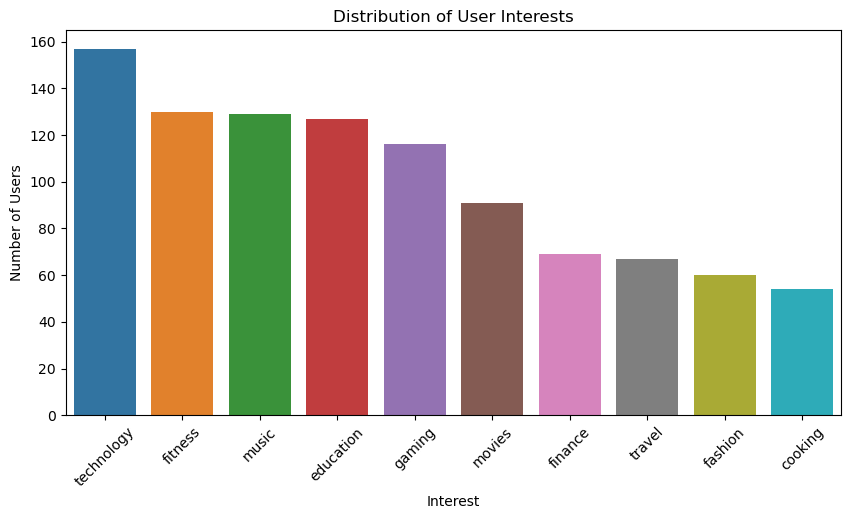

In [52]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_clean,
    x="interest",
    order=df_clean["interest"].value_counts().index
)

plt.title("Distribution of User Interests")
plt.xlabel("Interest")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

Technology is the most common user interest, followed by fitness, music, and education. 
Cooking and fashion are the least represented interests in the dataset.

#### Activity Type Distribution

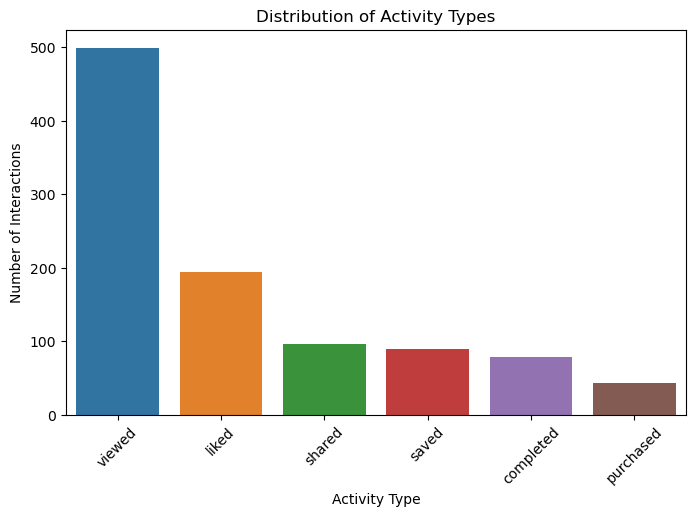

In [53]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="activity_type",
    order=df_clean["activity_type"].value_counts().index
)

plt.title("Distribution of Activity Types")
plt.xlabel("Activity Type")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=45)
plt.show()

Viewed is the most common activity type, while purchased is the least common. 
This is realistic because viewing content requires less effort than purchasing.

#### Engagement by Content Format

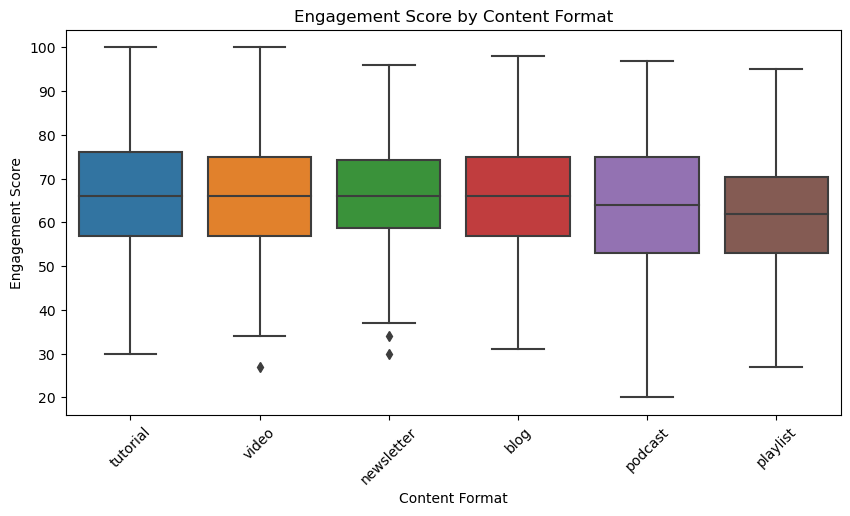

In [54]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x="content_format",
    y="engagement_score"
)

plt.title("Engagement Score by Content Format")
plt.xlabel("Content Format")
plt.ylabel("Engagement Score")
plt.xticks(rotation=45)
plt.show()

The boxplot shows that engagement scores are relatively balanced across content formats. 
Tutorial, video, newsletter, and blog formats have slightly higher median engagement scores, while podcast and playlist appear slightly lower.

The wide boxes and whiskers show that engagement varies within each format. 
This means that content format alone does not fully explain user engagement.

Content format may influence engagement, but it is not the only factor.

#### Correlation Heatmap

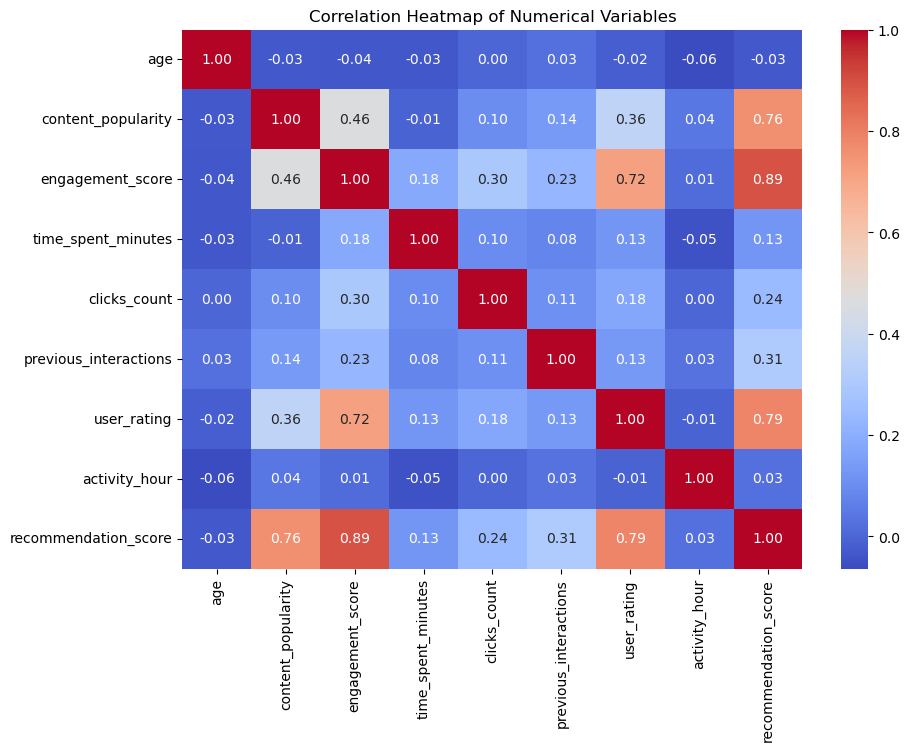

In [55]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

The heatmap shows that recommendation_score is strongly related to engagement_score, user_rating, and content_popularity. 
This makes sense because a good recommendation should be connected to user engagement, user satisfaction, and content popularity.

Engagement_score is also strongly related to user_rating and moderately related to content_popularity. 
Age and activity_hour have correlations close to zero, suggesting that they do not strongly influence engagement or recommendation score in this dataset.

#### Age Distribution

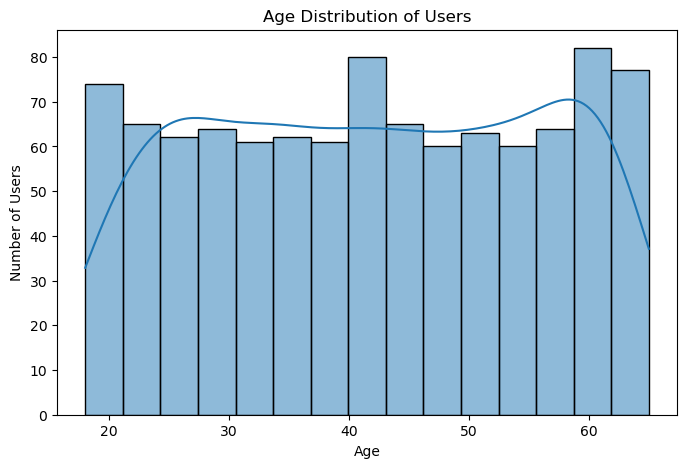

In [56]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=15,
    kde=True
)

plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()

The age distribution appears relatively balanced between 18 and 65 years old. 
No single age group strongly dominates the dataset, which suggests that the synthetic users represent a broad adult audience.

#### Content Category Distribution

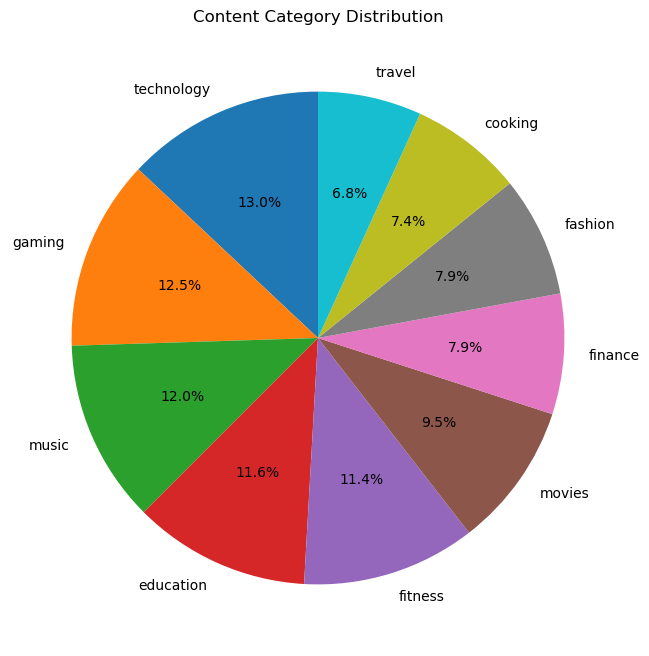

In [57]:
category_counts = df_clean["content_category"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Content Category Distribution")
plt.show()

The pie chart shows that technology, gaming, music, education, and fitness are among the most represented content categories. 
Travel, cooking, fashion, and finance have smaller proportions.

Overall, the dataset includes a variety of content categories, with no single category completely dominating the distribution.

#### Distribution of Normalized Recommendation Scores

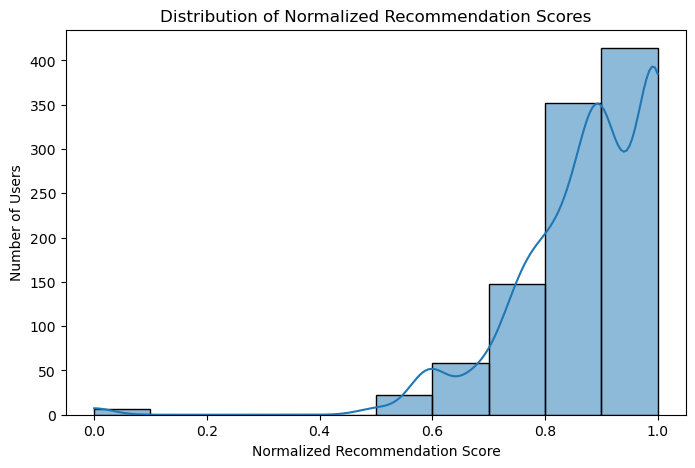

In [58]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="normalized_recommendation_score",
    bins=10,
    kde=True
)

plt.title("Distribution of Normalized Recommendation Scores")
plt.xlabel("Normalized Recommendation Score")
plt.ylabel("Number of Users")
plt.show()

This histogram shows how the normalized recommendation scores are distributed across users. 
Scores closer to 1 represent stronger matches between the user profile and the selected recommendation.

#### Activity Intensity by Hour and Content Category

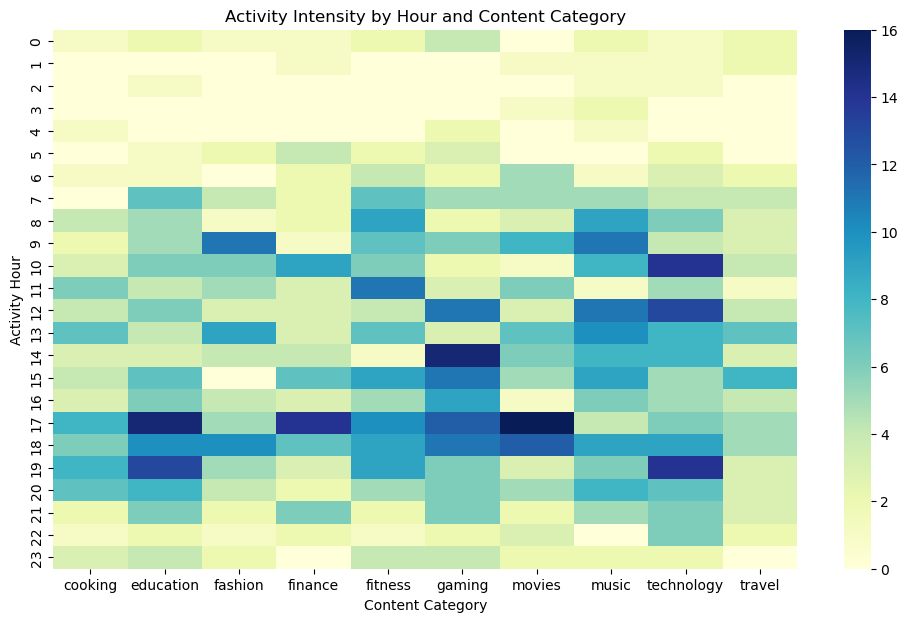

In [59]:
activity_hour_category = pd.crosstab(
    df_clean["activity_hour"],
    df_clean["content_category"]
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    activity_hour_category,
    cmap="YlGnBu"
)

plt.title("Activity Intensity by Hour and Content Category")
plt.xlabel("Content Category")
plt.ylabel("Activity Hour")
plt.show()

This heatmap shows user activity intensity by hour and content category. 
Darker colors represent higher numbers of interactions.

The highest activity appears around the late afternoon and evening, especially around 17:00 to 19:00. 
Some categories such as education, gaming, movies, and technology show stronger activity during these hours.

This supports the earlier finding that the peak activity hour is 17.

### Final Demo: User Recommendation Card

To make the recommendation system easier to understand, I created a final user card. 
It shows not only the recommendation, but also the information used to produce it.

This final demo selects one existing user from the dataset and displays the information used by the recommendation system. 
It shows the user's profile, interaction behavior, engagement signals, and final personalized recommendation.

Personalized User Recommendation Card

User Profile
------------------------------------
Name: Leah Moore
Age: 48
Main interest: technology
Preferred format: video

Recommended Content
------------------------------------
Recommended content: AI TUTORIAL VIDEO
Content category: technology
Content format: video
Content popularity: 100

Recommendation Score
------------------------------------
Candidate score: 23.0 out of 23.0
Normalized match score: 100.0 %

Top 5 Candidate Recommendations
------------------------------------
         recommended_content content_category content_format  \
941        AI tutorial video       technology          video   
55    Tech trends newsletter       technology          video   
333  Python programming blog       technology          video   
183  Python programming blog       technology          video   
937        AI tutorial video       technology          video   

     content_popularity  candidate_score  
941                 100            23.00 

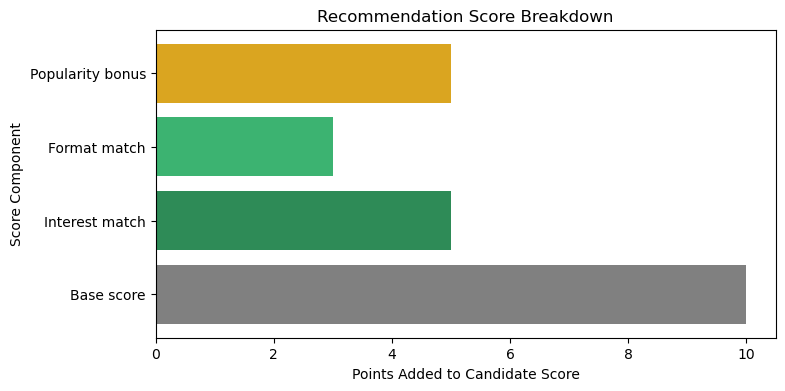

In [60]:
selected_user = df_clean.sample(1).iloc[0]

final_recommendation = find_best_recommendation(selected_user, candidate_contents)

user_candidate_scores = candidate_contents.copy()

user_candidate_scores["candidate_score"] = user_candidate_scores.apply(
    lambda candidate: score_candidate_for_user(selected_user, candidate),
    axis=1
)

top_5_candidates = user_candidate_scores.sort_values(
    "candidate_score",
    ascending=False
).head(5)

user_score = final_recommendation["candidate_score"]
user_recommendation = final_recommendation["recommended_content"]
score_percentage = round(selected_user["normalized_recommendation_score"] * 100, 1)

base_score = 10
interest_bonus = 5 if selected_user["interest"] == final_recommendation["content_category"] else 0
format_bonus = 3 if selected_user["preferred_format"] == final_recommendation["content_format"] else 0
popularity_bonus = final_recommendation["content_popularity"] / 20

score_parts = {
    "Base score": base_score,
    "Interest match": interest_bonus,
    "Format match": format_bonus,
    "Popularity bonus": popularity_bonus
}

print("Personalized User Recommendation Card")
print("====================================")
print()
print("User Profile")
print("------------------------------------")
print("Name:", selected_user["name"])
print("Age:", selected_user["age"])
print("Main interest:", selected_user["interest"])
print("Preferred format:", selected_user["preferred_format"])
print()
print("Recommended Content")
print("------------------------------------")
print("Recommended content:", user_recommendation.upper())
print("Content category:", final_recommendation["content_category"])
print("Content format:", final_recommendation["content_format"])
print("Content popularity:", final_recommendation["content_popularity"])
print()
print("Recommendation Score")
print("------------------------------------")
print("Candidate score:", round(user_score, 2), "out of", max_possible_candidate_score)
print("Normalized match score:", score_percentage, "%")

print()
print("Top 5 Candidate Recommendations")
print("------------------------------------")
print(top_5_candidates[[
    "recommended_content",
    "content_category",
    "content_format",
    "content_popularity",
    "candidate_score"
]])

plt.figure(figsize=(8, 4))

plt.barh(
    list(score_parts.keys()),
    list(score_parts.values()),
    color=["gray", "seagreen", "mediumseagreen", "goldenrod"]
)

plt.title("Recommendation Score Breakdown")
plt.xlabel("Points Added to Candidate Score")
plt.ylabel("Score Component")
plt.show()

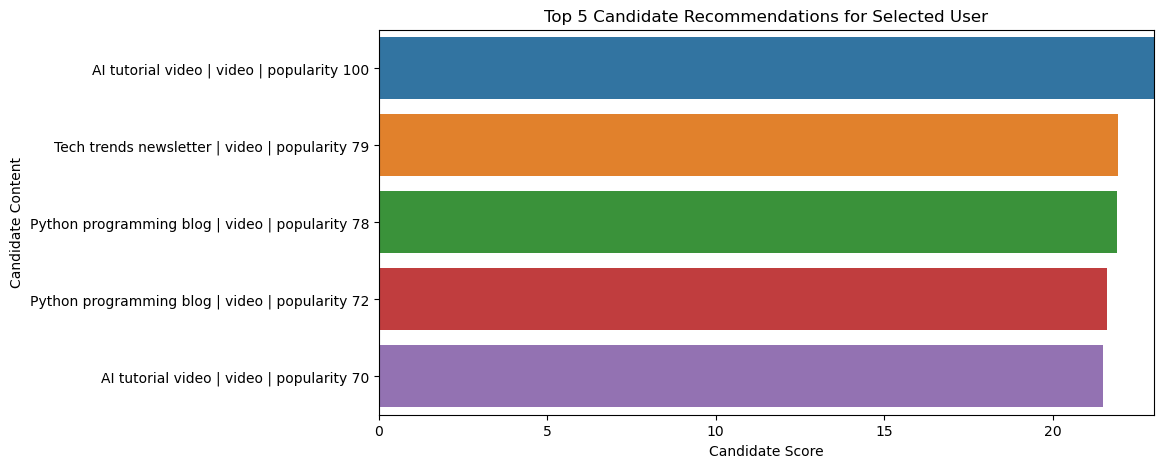

In [61]:
top_5_candidates = top_5_candidates.copy()

top_5_candidates["candidate_label"] = (
    top_5_candidates["recommended_content"]
    + " | "
    + top_5_candidates["content_format"]
    + " | popularity "
    + top_5_candidates["content_popularity"].astype(str)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_5_candidates,
    x="candidate_score",
    y="candidate_label",
    orient="h"
)

plt.title("Top 5 Candidate Recommendations for Selected User")
plt.xlabel("Candidate Score")
plt.ylabel("Candidate Content")
plt.xlim(0, max_possible_candidate_score)
plt.show()

This final demo shows one selected user and the top candidate recommendations generated for that user. 
The highest scoring candidate becomes the final personalized recommendation.

### Final Conclusion


This project shows how a synthetic user dataset can be used to build a simple personalized recommendation system.


The analysis showed that technology, fitness, music, and education were among the most common user interests. 
Viewed was the most frequent activity type, while purchased was much less common, which matches realistic user behavior.
The statistical analysis showed that content popularity has a significant positive relationship with engagement score. 
However, the chi-square test did not find a statistically significant relationship between user interest and activity type.


The recommendation engine uses simple rule-based logic instead of a complex machine learning model. 
It compares each user profile with candidate content options. 
It uses interest match, preferred format match, and content popularity to calculate a candidate score, then selects the highest scoring content as the final recommendation.



Overall, I enjoyed building this project because it helped me understand how data analysis can be connected to a practical recommendation system. 
Even with simple rules, the project shows how user preferences can be transformed into personalized suggestions that could be used in many digital interfaces, such as learning platforms, music apps, fitness apps, or content websites.


One thing I noticed is that working with synthetic data has limits. 
It was useful for learning and controlling the structure of the project, but real user data would probably make the insights more meaningful and less predictable.
In the future, this system could be improved with real user data, more detailed user history, or a machine learning-based recommendation model.
